In [2]:
import os
from typing import Annotated, TypedDict
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
load_dotenv()

True

In [3]:
import os
from langchain_openai import ChatOpenAI

# 1. Initialize the Generator with your primary OpenRouter key
generator_llm = ChatOpenAI(
    model="google/gemini-3-flash-preview",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"), # First Key
    max_tokens=1000
)

# 2. Initialize the Evaluator with your second specific key
evaluator_llm = ChatOpenAI(
    model="openai/gpt-4o-search-preview",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("gpt-4o-search-preview"), # Second Key
    max_tokens=1000
)
optimizer_llm = ChatOpenAI(
    model="google/gemini-3-flash-preview",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"), # First Key
    max_tokens=1000
)

In [4]:
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [5]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [6]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [7]:
# state
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [8]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [9]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [10]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [11]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

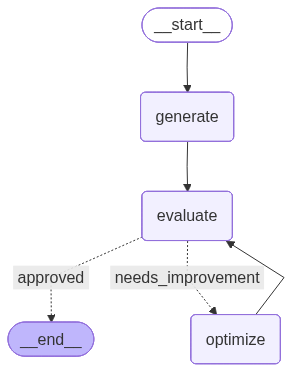

In [12]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

workflow

In [13]:
initial_state = {
    "topic": "sachin",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

APIStatusError: Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 1000 tokens, but can only afford 955. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'provider_name': None}}, 'user_id': 'user_32W4OGJwmIWWoXqGpifWwBEqeEe'}

In [ ]:
result

{'topic': 'sachin',
 'tweet': 'I’m convinced Sachin retired because he got tired of being the only reason 1 billion people didn\'t throw their TVs out the window every Sunday.\n\nIndian dads haven\'t "liked" a person since 2013. They just tolerate the rest of us while waiting for a straight drive to happen.',
 'evaluation': 'approved',
 'feedback': "The tweet is original and humorously captures the deep connection Indian cricket fans, especially fathers, had with Sachin Tendulkar. It effectively uses hyperbole to highlight Tendulkar's pivotal role in Indian cricket, suggesting his retirement left a void in fans' lives. The concise and witty format enhances its punchiness, making it likely to resonate and be shared among cricket enthusiasts. Overall, it meets the criteria for originality, humor, punchiness, virality potential, and proper tweet format.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['I’m convinced Sachin retired because he got tired of being the only reason 1 

In [ ]:
for tweet in result['tweet_history']:
    print(tweet)

I just hit my elbow against the doorframe so hard I accidentally typed "srhberhb" and honestly? It’s the most coherent thing I’ve said all week. It’s not a typo, it’s a lifestyle. It’s the sound of my soul leaving my body when I see my bank account balance.
